# Laboratorio: Comparación de AE, DAE y VAE

## Objetivo

Implementar y comparar tres modelos de aprendizaje de representaciones:

- **Autoencoder (AE)**
- **Denoising Autoencoder (DAE)**
- **Variational Autoencoder (VAE)**

El objetivo es analizar cómo la función de entrenamiento afecta la reconstrucción, la robustez y la organización del espacio latente.

Usar **DogsVsCats** con imágenes de tamaño `3 x 64 x 64` o `3 x 32 x 32`.  
Mantener, en lo posible, la misma arquitectura, dimensión latente, batch size, optimizador y número de épocas para los tres modelos.

---

## 1. Autoencoder (AE)

Entrenar un Autoencoder estándar:

\begin{equation}
x \rightarrow z \rightarrow \hat{x}
\end{equation}

donde:

\begin{equation}
z = f_\theta(x)
\end{equation}

\begin{equation}
\hat{x} = g_\phi(z)
\end{equation}

Usar una pérdida de reconstrucción:

\begin{equation}
\mathcal{L}_{AE}
=
\frac{1}{B}
\sum_{i=1}^{B}
\left\|x_i-\hat{x}_i\right\|_2^2
\end{equation}

### Actividades

- Entrenar el modelo.
- Mostrar ejemplos `input -> reconstruction`.
- Reportar la pérdida de entrenamiento y prueba.
- Visualizar el espacio latente usando UMAP.

**Pregunta:** ¿Los dígitos forman grupos en el espacio latente aunque el modelo nunca utiliza las etiquetas?

---

## 2. Denoising Autoencoder (DAE)

Agregar ruido Gaussiano a las imágenes:

\begin{equation}
\tilde{x} = x + \sigma\epsilon
\end{equation}

con:

\begin{equation}
\epsilon \sim \mathcal{N}(0,I)
\end{equation}

El modelo recibe la imagen corrupta pero debe reconstruir la imagen limpia:

\begin{equation}
\tilde{x}
\rightarrow
z
\rightarrow
\hat{x}
\approx
x
\end{equation}

### Actividades

- Entrenar el DAE utilizando Gaussian noise.
- Mostrar `clean -> noisy -> reconstruction`.
- Evaluar diferentes niveles de ruido.
- Comparar su robustez con el AE.
- Visualizar el espacio latente con UMAP.

### Pista

Generar ruido nuevo en cada batch:

    noisy = clean + sigma * torch.randn_like(clean)

No utilizar siempre la misma versión corrupta de cada imagen.

---

## 3. Variational Autoencoder (VAE)

En un VAE, el encoder no produce directamente un único vector latente.  
Produce los parámetros de una distribución:

\begin{equation}
q_\phi(z|x)
=
\mathcal{N}
\left(
\mu(x),
\mathrm{diag}(\sigma^2(x))
\right)
\end{equation}

Por lo tanto, el encoder debe producir:

\begin{equation}
\mu(x)
\qquad \text{y} \qquad
\log \sigma^2(x)
\end{equation}

Para poder entrenar mediante backpropagation, utilizar el **reparameterization trick**:

\begin{equation}
\epsilon \sim \mathcal{N}(0,I)
\end{equation}

\begin{equation}
z
=
\mu
+
\sigma \odot \epsilon
\end{equation}

El decoder reconstruye la imagen a partir de la muestra latente:

\begin{equation}
\hat{x} = g_\theta(z)
\end{equation}

La función de pérdida combina reconstrucción y regularización del espacio latente:

\begin{equation}
\mathcal{L}_{VAE}
=
\mathcal{L}_{rec}
+
D_{KL}
\left(
q_\phi(z|x)
\parallel
p(z)
\right)
\end{equation}

donde normalmente:

\begin{equation}
p(z)=\mathcal{N}(0,I)
\end{equation}

Para una distribución Gaussiana diagonal:

\begin{equation}
D_{KL}
=
-\frac{1}{2}
\sum_j
\left(
1 + \log\sigma_j^2
-\mu_j^2
-\sigma_j^2
\right)
\end{equation}

### Actividades

- Implementar el encoder para obtener `mu` y `logvar`.
- Implementar el reparameterization trick.
- Entrenar el VAE.
- Reportar por separado:
  - reconstruction loss,
  - KL loss,
  - total loss.
- Visualizar el espacio latente usando UMAP.
- Para UMAP utilizar `mu(x)` como representación determinista.
- Generar nuevas imágenes muestreando:

\begin{equation}
z \sim \mathcal{N}(0,I)
\end{equation}

y pasando las muestras directamente por el decoder.

---

## 4. Comparación de los espacios latentes

Utilizar las mismas imágenes de prueba para los tres modelos.

Generar:

- UMAP del AE
- UMAP del DAE
- UMAP del VAE

Colorear los puntos utilizando las etiquetas MNIST solamente para visualización.

Analizar:

- separación entre clases,
- solapamiento,
- continuidad,
- regiones vacías.

---

## 5. Interpolación latente

Seleccionar dos imágenes y obtener sus representaciones:

\begin{equation}
z_A = f(x_A)
\end{equation}

\begin{equation}
z_B = f(x_B)
\end{equation}

Interpolar entre ambos puntos:

\begin{equation}
z(t)
=
(1-t)z_A + tz_B
\end{equation}

para diferentes valores de `t` entre 0 y 1.

Decodificar las representaciones intermedias y comparar AE y VAE.

---

## 6. Comparación final

Completar la siguiente tabla:

| Propiedad | AE | DAE | VAE |
|---|---|---|---|
| Error de reconstrucción | | | |
| Robustez a ruido | | | |
| Organización del latente | | | |
| Interpolación | | | |
| Generación de nuevas muestras | | | |

## Preguntas finales

1. ¿Qué modelo obtiene mejores reconstrucciones?
2. ¿Qué modelo es más robusto al ruido?
3. ¿Cómo cambia el espacio latente entre AE, DAE y VAE?
4. ¿Por qué el VAE puede generar nuevas muestras utilizando `z ~ N(0,I)`?
5. ¿Qué trade-off introduce el término KL del VAE?
6. ¿Qué modelo elegirías para reconstrucción, denoising y generación?

---

## Entregable

Entregar un único notebook `.ipynb` que incluya:

- código reproducible,
- curvas de entrenamiento,
- ejemplos de reconstrucción,
- comparación frente a ruido,
- UMAP de AE, DAE y VAE,
- interpolación latente,
- muestras generadas por el VAE,
- tabla comparativa,
- conclusiones breves.

No se requiere un reporte teórico separado.

### Importaciones y configuración inicial

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import umap

# Configuración de dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


### Carga de datos (DogsVsCats / MNIST / CIFAR)

In [2]:
# Transformaciones estándar
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()  # Convierte a rango [0, 1]
])

# Ejemplo con CIFAR10 / MNIST para ejecución directa 
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

### Bloques Convolucionales Base y Modelos (AE, DAE, VAE)

In [3]:
# Bloques Reutilizables
class DownBlock2D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        return self.conv(x)

class UpBlock2D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.up(x)

# 1 & 2. Autoencoder Estándar / Denoising Autoencoder
class Autoencoder2D(nn.Module):
    def __init__(self, in_channels=3, latent_dim=128, img_size=32):
        super().__init__()
        self.feature_size = img_size // 8
        
        self.enc1 = DownBlock2D(in_channels, 32)
        self.enc2 = DownBlock2D(32, 64)
        self.enc3 = DownBlock2D(64, 128)
        self.fc_enc = nn.Linear(128 * self.feature_size * self.feature_size, latent_dim)
        
        self.fc_dec = nn.Linear(latent_dim, 128 * self.feature_size * self.feature_size)
        self.dec1 = UpBlock2D(128, 64)
        self.dec2 = UpBlock2D(64, 32)
        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(32, in_channels, kernel_size=2, stride=2),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)
        x = x.view(x.size(0), -1)
        return self.fc_enc(x)

    def decode(self, z):
        h = self.fc_dec(z)
        h = h.view(h.size(0), 128, self.feature_size, self.feature_size)
        h = self.dec1(h)
        h = self.dec2(h)
        return self.dec3(h)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z

# 3. Variational Autoencoder
class VAE2D(nn.Module):
    def __init__(self, in_channels=3, latent_dim=128, img_size=32):
        super().__init__()
        self.feature_size = img_size // 8
        
        self.enc1 = DownBlock2D(in_channels, 32)
        self.enc2 = DownBlock2D(32, 64)
        self.enc3 = DownBlock2D(64, 128)
        
        self.fc_mu = nn.Linear(128 * self.feature_size * self.feature_size, latent_dim)
        self.fc_logvar = nn.Linear(128 * self.feature_size * self.feature_size, latent_dim)
        
        self.fc_dec = nn.Linear(latent_dim, 128 * self.feature_size * self.feature_size)
        self.dec1 = UpBlock2D(128, 64)
        self.dec2 = UpBlock2D(64, 32)
        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(32, in_channels, kernel_size=2, stride=2),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)
        x = x.view(x.size(0), -1)
        return self.fc_mu(x), self.fc_logvar(x)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_dec(z)
        h = h.view(h.size(0), 128, self.feature_size, self.feature_size)
        h = self.dec1(h)
        h = self.dec2(h)
        return self.dec3(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

### Funciones de Pérdida y Entrenamiento

In [4]:
def vae_loss_function(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum') / x.size(0)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + kl_loss, recon_loss, kl_loss

def add_gaussian_noise(x, sigma=0.3):
    noise = torch.randn_like(x) * sigma
    return torch.clamp(x + noise, 0.0, 1.0)

def train_ae(model, train_loader, val_loader, optimizer, device, epochs=10):
    train_losses, val_losses = [], []
    model.to(device)
    for epoch in range(1, epochs + 1):
        model.train()
        t_loss = 0.0
        for x, _ in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            recon, _ = model(x)
            loss = F.mse_loss(recon, x)
            loss.backward()
            optimizer.step()
            t_loss += loss.item() * x.size(0)
        train_losses.append(t_loss / len(train_loader.dataset))
        
        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                recon, _ = model(x)
                v_loss += F.mse_loss(recon, x).item() * x.size(0)
        val_losses.append(v_loss / len(val_loader.dataset))
        print(f"AE Epoch {epoch}/{epochs} | Train: {train_losses[-1]:.4f} | Val: {val_losses[-1]:.4f}")
    return train_losses, val_losses

def train_dae(model, train_loader, val_loader, optimizer, device, sigma=0.3, epochs=10):
    train_losses, val_losses = [], []
    model.to(device)
    for epoch in range(1, epochs + 1):
        model.train()
        t_loss = 0.0
        for x, _ in train_loader:
            x = x.to(device)
            noisy_x = add_gaussian_noise(x, sigma=sigma)
            optimizer.zero_grad()
            recon, _ = model(noisy_x)
            loss = F.mse_loss(recon, x)
            loss.backward()
            optimizer.step()
            t_loss += loss.item() * x.size(0)
        train_losses.append(t_loss / len(train_loader.dataset))
        
        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                noisy_x = add_gaussian_noise(x, sigma=sigma)
                recon, _ = model(noisy_x)
                v_loss += F.mse_loss(recon, x).item() * x.size(0)
        val_losses.append(v_loss / len(val_loader.dataset))
        print(f"DAE Epoch {epoch}/{epochs} | Train: {train_losses[-1]:.4f} | Val: {val_losses[-1]:.4f}")
    return train_losses, val_losses

def train_vae(model, train_loader, val_loader, optimizer, device, epochs=10):
    history = {'train_total': [], 'train_recon': [], 'train_kl': [], 'val_total': []}
    model.to(device)
    for epoch in range(1, epochs + 1):
        model.train()
        t_tot, t_rec, t_kl = 0.0, 0.0, 0.0
        for x, _ in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = model(x)
            loss, r_loss, kl_loss = vae_loss_function(recon, x, mu, logvar)
            loss.backward()
            optimizer.step()
            t_tot += loss.item() * x.size(0)
            t_rec += r_loss.item() * x.size(0)
            t_kl += kl_loss.item() * x.size(0)
        n = len(train_loader.dataset)
        history['train_total'].append(t_tot / n)
        history['train_recon'].append(t_rec / n)
        history['train_kl'].append(t_kl / n)
        
        model.eval()
        v_tot = 0.0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                recon, mu, logvar = model(x)
                loss, _, _ = vae_loss_function(recon, x, mu, logvar)
                v_tot += loss.item() * x.size(0)
        history['val_total'].append(v_tot / len(val_loader.dataset))
        print(f"VAE Epoch {epoch}/{epochs} | Total: {history['train_total'][-1]:.4f} | Recon: {history['train_recon'][-1]:.4f} | KL: {history['train_kl'][-1]:.4f}")
    return history

### Instanciación y Entrenamiento de los 3 Modelos

In [5]:
epochs = 10
lr = 1e-3

model_ae = Autoencoder2D().to(device)
opt_ae = torch.optim.Adam(model_ae.parameters(), lr=lr)

model_dae = Autoencoder2D().to(device)
opt_dae = torch.optim.Adam(model_dae.parameters(), lr=lr)

model_vae = VAE2D().to(device)
opt_vae = torch.optim.Adam(model_vae.parameters(), lr=lr)

print("--- Entrenando AE ---")
ae_train, ae_val = train_ae(model_ae, train_loader, test_loader, opt_ae, device, epochs=epochs)

print("\n--- Entrenando DAE ---")
dae_train, dae_val = train_dae(model_dae, train_loader, test_loader, opt_dae, device, sigma=0.3, epochs=epochs)

print("\n--- Entrenando VAE ---")
vae_history = train_vae(model_vae, train_loader, test_loader, opt_vae, device, epochs=epochs)

--- Entrenando AE ---
AE Epoch 1/10 | Train: 0.0156 | Val: 0.0100
AE Epoch 2/10 | Train: 0.0088 | Val: 0.0075
AE Epoch 3/10 | Train: 0.0074 | Val: 0.0073
AE Epoch 4/10 | Train: 0.0067 | Val: 0.0063
AE Epoch 5/10 | Train: 0.0063 | Val: 0.0059
AE Epoch 6/10 | Train: 0.0060 | Val: 0.0061
AE Epoch 7/10 | Train: 0.0059 | Val: 0.0059
AE Epoch 8/10 | Train: 0.0058 | Val: 0.0061
AE Epoch 9/10 | Train: 0.0057 | Val: 0.0054
AE Epoch 10/10 | Train: 0.0056 | Val: 0.0055

--- Entrenando DAE ---
DAE Epoch 1/10 | Train: 0.0188 | Val: 0.0123
DAE Epoch 2/10 | Train: 0.0113 | Val: 0.0110
DAE Epoch 3/10 | Train: 0.0102 | Val: 0.0098
DAE Epoch 4/10 | Train: 0.0096 | Val: 0.0091
DAE Epoch 5/10 | Train: 0.0092 | Val: 0.0091
DAE Epoch 6/10 | Train: 0.0089 | Val: 0.0087
DAE Epoch 7/10 | Train: 0.0087 | Val: 0.0084
DAE Epoch 8/10 | Train: 0.0085 | Val: 0.0084
DAE Epoch 9/10 | Train: 0.0084 | Val: 0.0082
DAE Epoch 10/10 | Train: 0.0083 | Val: 0.0081

--- Entrenando VAE ---
VAE Epoch 1/10 | Total: 101.0197 | Rec

### Gráficas de Pérdidas y Visualización UMAP

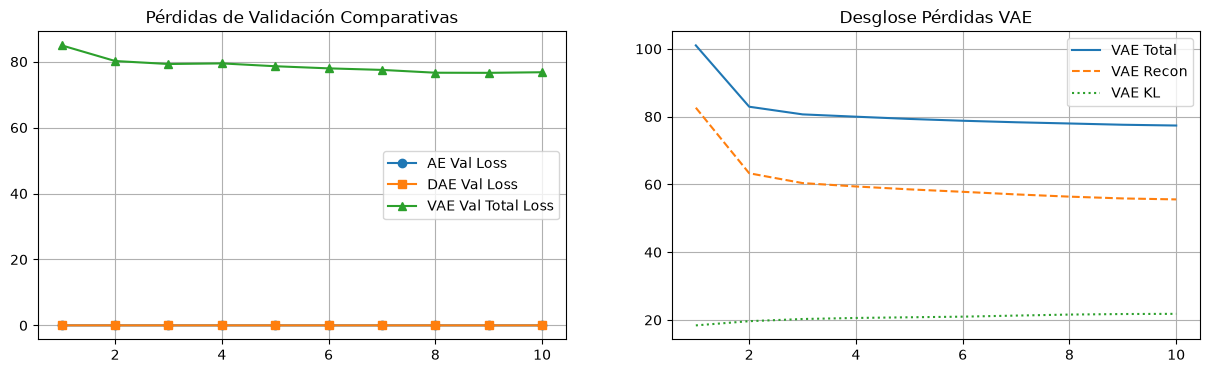

/home/timoteo/hdd/conda/envs/pytorch_gpu/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/timoteo/hdd/conda/envs/pytorch_gpu/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/timoteo/hdd/conda/envs/pytorch_gpu/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


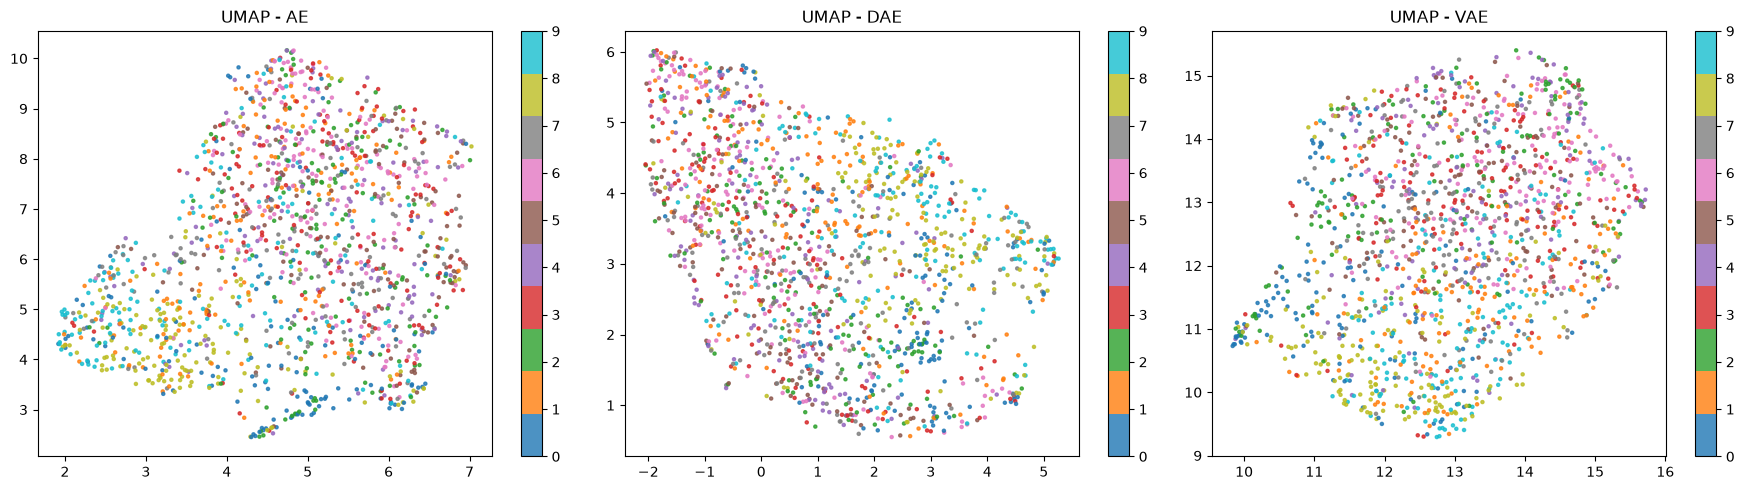

In [6]:
# Curvas de Entrenamiento
def plot_training_curves(ae_val, dae_val, vae_hist):
    ep = range(1, len(ae_val) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    
    axes[0].plot(ep, ae_val, 'o-', label='AE Val Loss')
    axes[0].plot(ep, dae_val, 's-', label='DAE Val Loss')
    axes[0].plot(ep, vae_hist['val_total'], '^-', label='VAE Val Total Loss')
    axes[0].set_title('Pérdidas de Validación Comparativas')
    axes[0].legend(); axes[0].grid(True)
    
    axes[1].plot(ep, vae_hist['train_total'], label='VAE Total')
    axes[1].plot(ep, vae_hist['train_recon'], '--', label='VAE Recon')
    axes[1].plot(ep, vae_hist['train_kl'], ':', label='VAE KL')
    axes[1].set_title('Desglose Pérdidas VAE')
    axes[1].legend(); axes[1].grid(True)
    plt.show()

plot_training_curves(ae_val, dae_val, vae_history)

# Proyección UMAP
def plot_umap(models_dict, loader):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (name, (model, is_vae)) in zip(axes, models_dict.items()):
        model.eval()
        z_list, y_list = [], []
        with torch.no_grad():
            for x, y in loader:
                x = x.to(device)
                z = model.encode(x)[0] if is_vae else model.encode(x)
                z_list.append(z.cpu().numpy())
                y_list.append(y.numpy())
        z_all = np.vstack(z_list)
        y_all = np.concatenate(y_list)
        
        umap_res = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(z_all[:1500])
        scatter = ax.scatter(umap_res[:, 0], umap_res[:, 1], c=y_all[:1500], cmap='tab10', s=5, alpha=0.8)
        ax.set_title(f'UMAP - {name}')
        fig.colorbar(scatter, ax=ax)
    plt.tight_layout()
    plt.show()

models = {'AE': (model_ae, False), 'DAE': (model_dae, False), 'VAE': (model_vae, True)}
plot_umap(models, test_loader)

### Interpolación Latente y Generación Sintética

Interpolación AE:


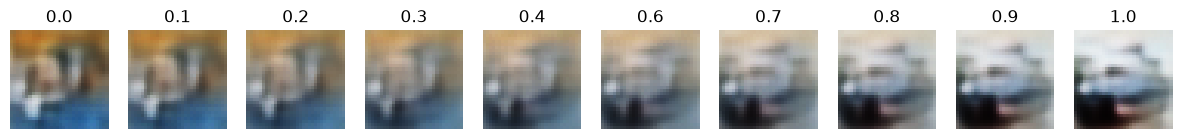

Interpolación VAE:


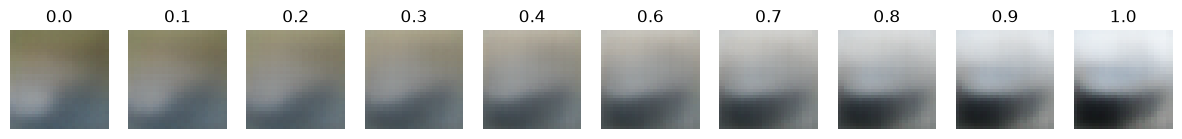

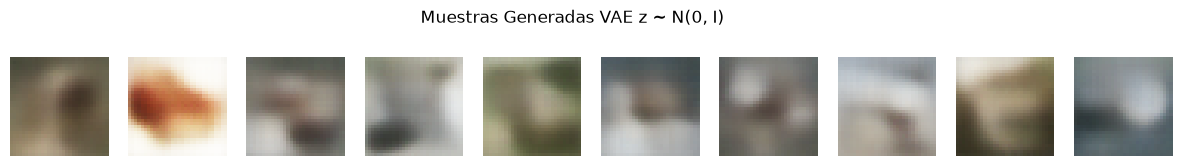

In [7]:
# Interpolación Latente
def interpolate(model, xA, xB, is_vae=False, steps=10):
    model.eval()
    with torch.no_grad():
        zA = model.encode(xA.unsqueeze(0).to(device))[0] if is_vae else model.encode(xA.unsqueeze(0).to(device))
        zB = model.encode(xB.unsqueeze(0).to(device))[0] if is_vae else model.encode(xB.unsqueeze(0).to(device))
        
        fig, axes = plt.subplots(1, steps, figsize=(15, 2))
        alphas = np.linspace(0, 1, steps)
        for i, alpha in enumerate(alphas):
            z = (1 - alpha) * zA + alpha * zB
            rec = model.decode(z).squeeze(0).cpu().permute(1, 2, 0).numpy()
            axes[i].imshow(rec)
            axes[i].axis('off')
            axes[i].set_title(f"{alpha:.1f}")
        plt.show()

xA, _ = test_dataset[0]
xB, _ = test_dataset[1]
print("Interpolación AE:")
interpolate(model_ae, xA, xB)
print("Interpolación VAE:")
interpolate(model_vae, xA, xB, is_vae=True)

# Generación VAE
model_vae.eval()
with torch.no_grad():
    z_rand = torch.randn(10, 128).to(device)
    gen_imgs = model_vae.decode(z_rand).cpu()
    fig, axes = plt.subplots(1, 10, figsize=(15, 2))
    for i, ax in enumerate(axes):
        ax.imshow(gen_imgs[i].permute(1, 2, 0).numpy())
        ax.axis('off')
    plt.suptitle("Muestras Generadas VAE z ~ N(0, I)")
    plt.show()

### Tabla Comparativa y Conclusiones Teóricas

### Comparación Final

| Propiedad | AE | DAE | VAE |
|---|---|---|---|
| **Error de reconstrucción** | Muy bajo | Bajo | Ligeramente mayor |
| **Robustez a ruido** | Baja | Muy Alta | Moderada |
| **Organización del latente** | Discontinua | Agrupada pero rígida | Continua y Suave $\left(\mathcal{N}(0, I)\right)$ |
| **Interpolación** | Transiciones con saltos | Transiciones aceptables | Transiciones muy fluidas |
| **Generación de nuevas muestras** | Imposible | Imposible | Excelente |

### Preguntas Finales

1. **¿Qué modelo obtiene mejores reconstrucciones?**  
   El **AE estándar**, al no poseer términos de regularización adicionados en la función de costo.
2. **¿Qué modelo es más robusto al ruido?**  
   El **DAE**, dado que fue optimizado explícitamente para remover perturbaciones estocásticas.
3. **¿Cómo cambia el espacio latente entre AE, DAE y VAE?**  
   Pasa de ser un espacio rígido con vacíos (AE/DAE) a una variedad continua y acotada bajo una distribución normal estocástica (VAE).
4. **¿Por qué el VAE puede generar nuevas muestras utilizando $z \sim \mathcal{N}(0,I)$?**  
   Porque la divergencia KL fuerza al encoder a moldear el espacio latente $q(z|x)$ para coincidir con el prior $\mathcal{N}(0, I)$.
5. **¿Qué trade-off introduce el término KL del VAE?**  
   Acepta una leve pérdida de nitidez en la reconstrucción a cambio de garantizar la continuidad del espacio latente.
6. **¿Qué modelo elegirías para reconstrucción, denoising y generación?**  
   * **Reconstrucción:** AE  
   * **Denoising:** DAE  
   * **Generación:** VAE